<a href="https://colab.research.google.com/github/00015775/learning-lab/blob/learn%2Fpytorch/pytorch/notebooks/04_youtube_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PyTorch Datasets

* `torchvision.datasets` - Computer Vision https://docs.pytorch.org/vision/main/datasets.html

* `torchtext.datasets` - Text (or NLP) https://docs.pytorch.org/text/stable/datasets.html


* `torchaudio.datasets` - Audio (or NLP) https://docs.pytorch.org/audio/stable/datasets.html


* `torchrec.datasets` - Recommendation system
https://docs.pytorch.org/text/stable/datasets.html



In [104]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.transforms import ToTensor
import sys

print(torch.__version__)
print(torchvision.__version__)
print(sys.version)

2.9.0+cu126
0.24.0+cu126
3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


`ToTensor`

Converts a PIL Image or numpy.ndarray `(H x W x C)` in the range
[0, 255] to a torch.FloatTensor of shape `(C x H x W)` in the range [0.0, 1.0]
if the PIL Image belongs to one of the modes (L, LA, P, I, F, RGB, YCbCr, RGBA, CMYK, 1)
or if the numpy.ndarray has dtype = np.uint8

In the other cases, tensors are returned without scaling.

In [105]:
device = torch.device("cuda" if torch.cuda.is_available()\
                      else "cpu")

device

device(type='cuda')

* Start with small subsets of the dataset\

* It is import to start with small scale and then scale up if needed

In [106]:
import requests
import zipfile
from pathlib import Path

DATA_PATH = Path("./data/")
IMAGE_PATH = DATA_PATH / "pizza_steak_sushi"

# check if folder already exists or not, to avoid erros and overwriting data
if IMAGE_PATH.is_dir():
  print(f"{IMAGE_PATH} already exists, skipping download ... ")
else:
  print(f"{IMAGE_PATH} does not exist, creating one ... ")
  IMAGE_PATH.mkdir(parents=True, exist_ok=True)


data/pizza_steak_sushi already exists, skipping download ... 


In [107]:
# download from github
with open(IMAGE_PATH / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
  print("Downloading pizza, steak, sushi data ... ")
  f.write(request.content)

# unzip
with zipfile.ZipFile(IMAGE_PATH / "pizza_steak_sushi.zip", "r") as zip_ref:
  print("Unzipping pizza, steak and sushi data ... ")
  zip_ref.extractall(IMAGE_PATH)

Unzipping pizza, steak and sushi data ... 


In [108]:
IMAGE_PATH

PosixPath('data/pizza_steak_sushi')

In [109]:
DATA_PATH

PosixPath('data')

In [110]:
# stopped at 20:12

In [111]:
!ls ./data/pizza_steak_sushi/

pizza_steak_sushi.zip  test  train


In [112]:
!ls ./data/pizza_steak_sushi/test

pizza  steak  sushi


In [113]:
!ls ./data/pizza_steak_sushi/train

pizza  steak  sushi


In [114]:
import os

def walk_through_dir(dir_path):
  """Walks through dir_path returning its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}.")


In [115]:
walk_through_dir(IMAGE_PATH)

There are 2 directories and 1 images in data/pizza_steak_sushi.
There are 3 directories and 0 images in data/pizza_steak_sushi/train.
There are 0 directories and 72 images in data/pizza_steak_sushi/train/sushi.
There are 0 directories and 75 images in data/pizza_steak_sushi/train/steak.
There are 0 directories and 78 images in data/pizza_steak_sushi/train/pizza.
There are 3 directories and 0 images in data/pizza_steak_sushi/test.
There are 0 directories and 31 images in data/pizza_steak_sushi/test/sushi.
There are 0 directories and 19 images in data/pizza_steak_sushi/test/steak.
There are 0 directories and 25 images in data/pizza_steak_sushi/test/pizza.


In [116]:
train_dir = IMAGE_PATH / "train"
test_dir = IMAGE_PATH / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

## Visualizing image

In [117]:
!pip list | grep pillow

pillow                                   11.3.0


data/pizza_steak_sushi/train/sushi/1138695.jpg
sushi
512
512


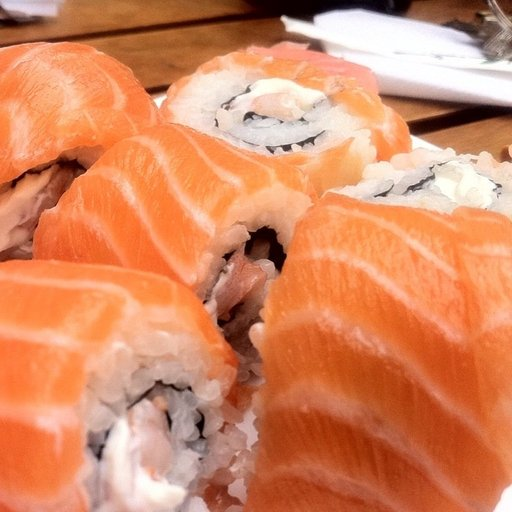

In [118]:
import matplotlib.pyplot as plt
import random
from PIL import Image

#random.seed(56)

image_path_list = list(IMAGE_PATH.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)

print(random_image_path)

image_class = random_image_path.parent.stem

print(image_class)

img = Image.open(random_image_path)

print(img.height)
print(img.width)

img

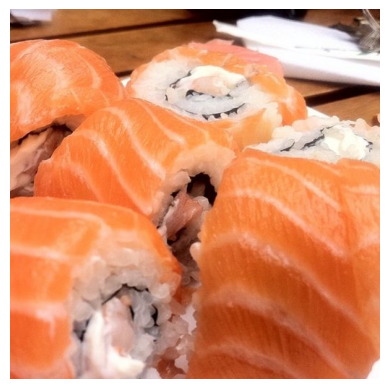

In [119]:
plt.imshow(img)
plt.axis(False)
plt.show()

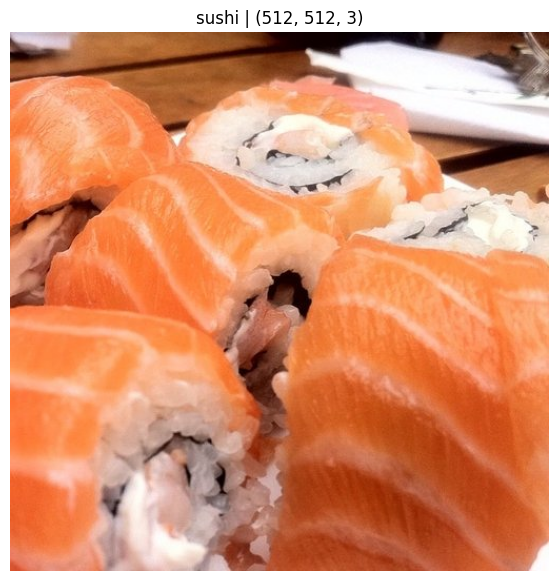

In [120]:
import numpy as np
import matplotlib.pyplot as plt


img_as_array = np.asarray(img)
plt.figure(figsize=(10,7))

plt.imshow(img_as_array)
plt.title(f"{image_class} | {img_as_array.shape}")
plt.axis(False)
plt.show()

array([[[195, 177, 193],
        [197, 179, 195],
        [203, 186, 202],
        ...,
        [ 66,  19,   9],
        [ 60,  16,   7],
        [ 64,  20,  11]],

       [[186, 168, 184],
        [200, 182, 198],
        [208, 191, 207],
        ...,
        [ 69,  22,  12],
        [ 64,  20,   9],
        [ 68,  24,  13]],

       [[176, 158, 172],
        [193, 175, 189],
        [205, 188, 204],
        ...,
        [ 72,  26,  13],
        [ 69,  23,  10],
        [ 74,  28,  15]],

       ...,

       [[219,  87,  49],
        [218,  86,  48],
        [218,  85,  50],
        ...,
        [254, 253, 251],
        [255, 253, 254],
        [254, 254, 255]],

       [[218,  86,  48],
        [217,  85,  47],
        [217,  83,  46],
        ...,
        [254, 253, 251],
        [255, 253, 254],
        [254, 254, 254]],

       [[217,  85,  47],
        [216,  84,  46],
        [216,  82,  45],
        ...,
        [254, 253, 251],
        [255, 253, 254],
        [254, 254, 254]]], dtype=uint8)
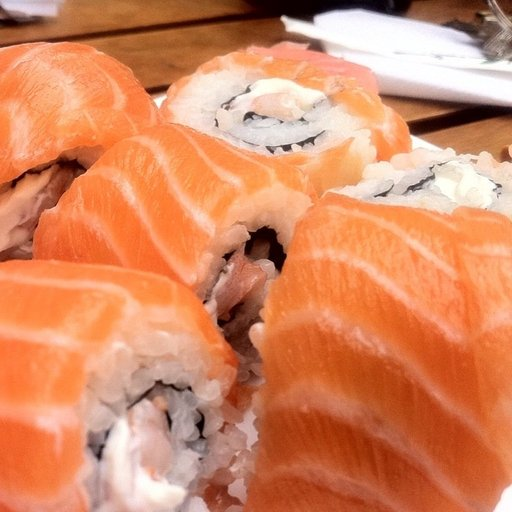

In [121]:
img_as_array

In [122]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models

In [123]:
data_transform = transforms.Compose([
    # resize images to 64x64
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor() # (H,W,C) -> (C,H,W)
])

data_transform

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
)

`torchvision.transforms` - https://docs.pytorch.org/vision/0.8/transforms.html

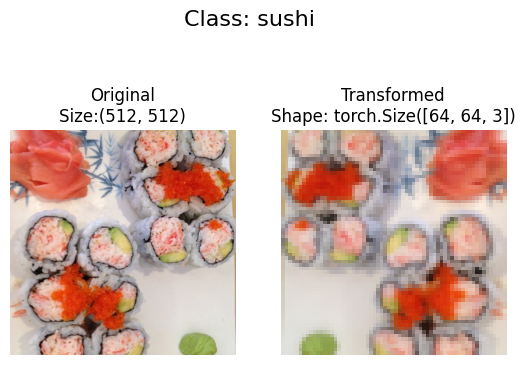

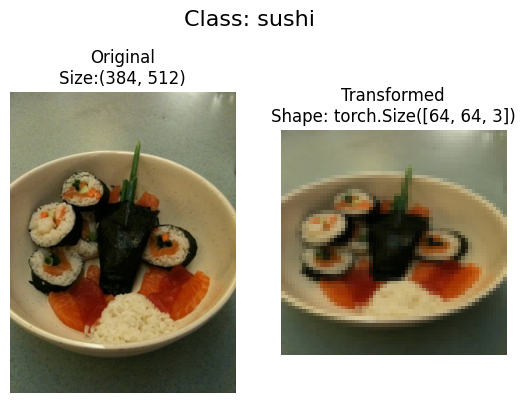

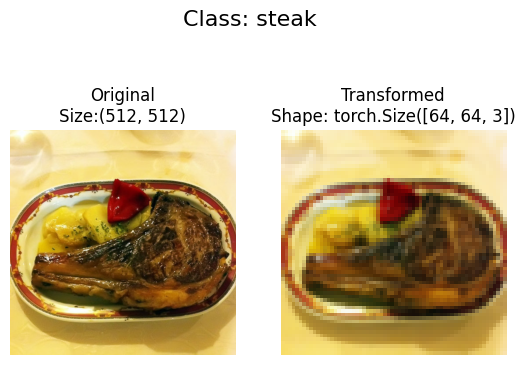

In [124]:
import numpy as np
import random

def plot_transformed_images(image_paths, transform, n=3, seed=42):
  """Some information here"""
  if seed:
    random.seed(seed)


  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1, ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\nSize:{f.size}")
      ax[0].axis(False)

      transformed_image = transform(f).permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis(False)

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)


plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=42)


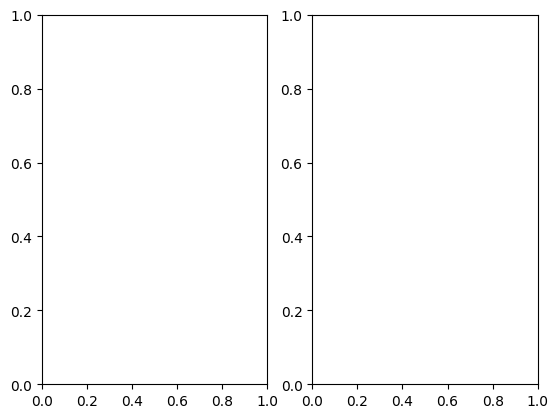

In [125]:
fig, ax = plt.subplots(nrows=1, ncols=2)

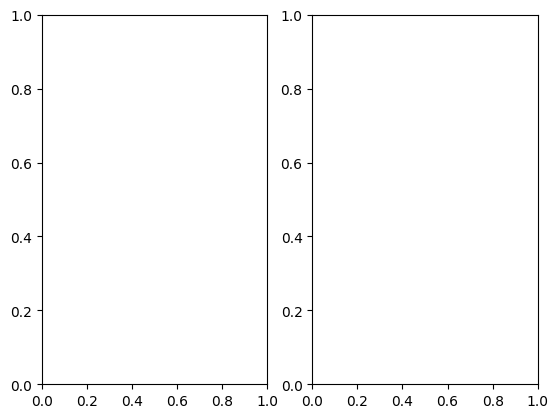

In [126]:
fig

In [127]:
ax

array([<Axes: >, <Axes: >], dtype=object)

In [128]:
ax[0]

<Axes: >

In [129]:
ax[1]

<Axes: >

In [130]:
from torchvision import datasets

train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform,
                                  target_transform=None)


test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform,
                                 target_transform=None) # transformations for Y_True

In [131]:
train_data

Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )

In [132]:
test_data

Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )

In [133]:
dir(test_data)

['__add__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_format_transform_repr',
 '_repr_indent',
 'class_to_idx',
 'classes',
 'extensions',
 'extra_repr',
 'find_classes',
 'imgs',
 'loader',
 'make_dataset',
 'root',
 'samples',
 'target_transform',
 'targets',
 'transform',
 'transforms']

In [134]:
class_names = train_data.classes

class_names

['pizza', 'steak', 'sushi']

In [135]:
class_dict = train_data.class_to_idx

class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [136]:
len(train_data), len(test_data)

(225, 75)

In [137]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [138]:
train_data.targets[0]

0

In [139]:
train_data[0][0].shape

torch.Size([3, 64, 64])

In [140]:
img, label = train_data[0][0], train_data[0][1]

torch.Size([3, 64, 64])
torch.Size([64, 64, 3])


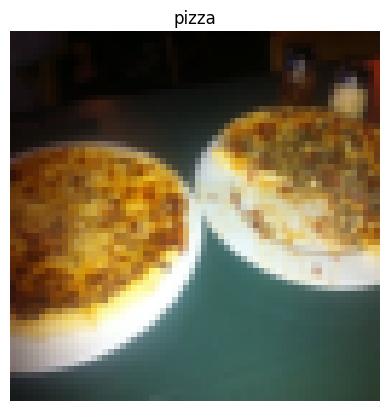

In [141]:
plt.imshow(img.permute(1,2,0))
print(img.shape)
print(img.permute(1,2,0).shape)
plt.axis("off")
plt.title(f"{class_names[label]}")
plt.show()

In [142]:
import os

os.cpu_count() # two CPU cores, used for num_workers

2

In [143]:
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=os.cpu_count(),
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=os.cpu_count(),
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7828cda6d7f0>,
 <torch.utils.data.dataloader.DataLoader at 0x7828cc2c0bc0>)

In [144]:
len(train_dataloader), len(test_dataloader)

(8, 3)

In [145]:
len(train_data), len(test_data)

(225, 75)

In [146]:
225/32, 75/32 # rounded up

(7.03125, 2.34375)

In [147]:
225/BATCH_SIZE, 75/BATCH_SIZE

(7.03125, 2.34375)

In [148]:
img, label = next(iter(train_dataloader))

display(img.shape, label.shape)

torch.Size([32, 3, 64, 64])

torch.Size([32])

## Loading Image data with custom `Dataset`

In [149]:
import os
import pathlib

import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

from typing import Tuple, Dict, List

In [150]:
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

* Get the class names using `os.scandir()`
* Raise an error if the class names aren't found
* Turn the class names into a dict and a list and return them

In [151]:
# stopped at 21:35

In [152]:
target_directory = train_dir
target_directory

PosixPath('data/pizza_steak_sushi/train')

In [153]:
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])

class_names_found

['pizza', 'steak', 'sushi']

In [154]:
list(os.scandir(target_directory))

[<DirEntry 'sushi'>, <DirEntry 'steak'>, <DirEntry 'pizza'>]

In [155]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  # if nothing is within the directory
  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory} ...")


  class_to_idx = {class_name: i for i, class_name in enumerate(classes)}

  return classes, class_to_idx


In [156]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

## Create a custom dataset using `torch.utils.data.Dataset`

* Subclass `torch.utils.data.Dataset`
* paths
* transform
* classes
* class_to_idx

In [157]:
from torch.utils.data import Dataset

class CustomDataset(Dataset):

  def __init__(self,
               targ_dir: str,
               transform=None):
    self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
    self.transform = transform
    self.classes, self.class_to_idx = find_classes(targ_dir)

  def load_image(self, index: int) -> Image.Image:
    image_path = self.paths[index]
    return Image.open(image_path)

  def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
    img = self.load_image(index)
    class_name = self.paths[index].parent.name
    class_idx = self.class_to_idx[class_name]

    if self.transform:
      return self.transform(img), class_idx
    else:
      return img, class_idx

  def __len__(self) -> int:
    return len(self.paths)


In [158]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(0.6),
    transforms.ToTensor()
])

# no augmentation for the testing dataset
test_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [159]:
train_data_custom = CustomDataset(targ_dir=train_dir,
                                  transform=train_transforms)

test_data_custom = CustomDataset(targ_dir=test_dir,
                                 transform=test_transforms)

In [160]:
len(train_data_custom), len(test_data_custom)

(225, 75)

In [161]:
train_data_custom, test_data_custom

(<__main__.CustomDataset at 0x7828cdae7a70>,
 <__main__.CustomDataset at 0x7828cc2c0b30>)

In [162]:
len(train_data), len(test_data)

(225, 75)

In [163]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [164]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [165]:
train_data_custom.transform

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.6)
    ToTensor()
)

In [166]:
print(train_data_custom.classes==train_data.classes)

True


In [167]:
print(test_data_custom.classes==test_data.classes)

True


In [168]:

def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
  if n > 10:
    n = 10
    display_shape = False
    print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")


  if seed:
    random.seed(seed)

  # get random indexes
  random_samples_idx = random.sample(range(len(dataset)), k=n)

  # loop through random indexes and plot them with plt
  for i, targ_sample in enumerate(random_samples_idx):
    targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][0]

    targ_image_adjust = targ_image.permute(1, 2, 0) # HWC -> CHW

    plt.subplot(1, n, i+1)
    plt.imshow(targ_image_adjust)
    plt.axis("off")

    # if classes:
    #   title = f"Class: {classes[targ_label]}"
    #   if display_shape:
    #     title = title + f"\nshape: {targ_image_adjust.shape}"
    # plt.title(title)


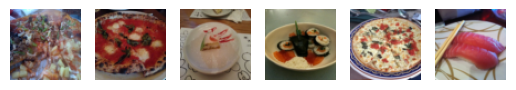

In [169]:
display_random_images(dataset=train_data,
                      n=6,
                      classes=class_names,
                      seed=None)

In [170]:
# stopped at 22:20

In [171]:
import os

from torch.utils.data import DataLoader

train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=16,
                                     num_workers=os.cpu_count(),
                                     shuffle=True)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size=16,
                                    num_workers=os.cpu_count(),
                                    shuffle=False) # for consistent comparison

In [172]:
len(train_dataloader_custom), len(test_dataloader_custom)

(15, 5)

In [173]:
len(train_data_custom), len(test_data_custom)

(225, 75)

In [174]:
img_custom, label_custom = next(iter(train_dataloader_custom))

img_custom.shape, label_custom.shape

(torch.Size([16, 3, 64, 64]), torch.Size([16]))

In [175]:
img_custom.dtype, label_custom.dtype

(torch.float32, torch.int64)

In [176]:
train_transforms = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=32),
    transforms.ToTensor()
])

In [177]:
IMAGE_PATH

PosixPath('data/pizza_steak_sushi')

In [178]:
image_path_list = list(IMAGE_PATH.glob("*/*/*.jpg"))

image_path_list[:5]

[PosixPath('data/pizza_steak_sushi/train/sushi/765684.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/385154.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/686426.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1957449.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/3004029.jpg')]

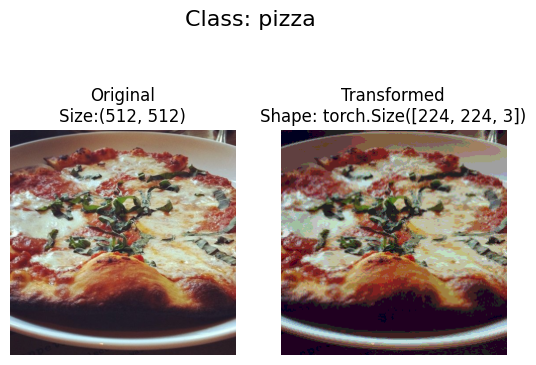

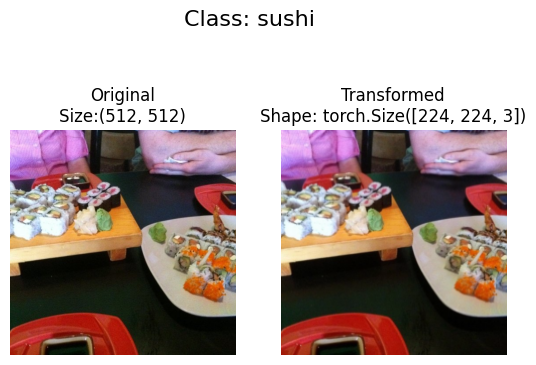

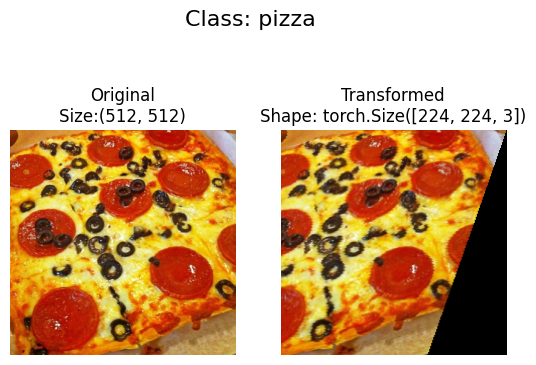

In [179]:
plot_transformed_images(image_paths=image_path_list,
                        transform=train_transforms,
                        n=3,
                        seed=None)

## Base Model 0

In [180]:
simple_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor(), # HWC (0, 255) -> CHW (0.0, 1.0)
])

In [181]:
from torchvision import datasets

train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_transform)

test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=simple_transform)

import os
from torch.utils.data import DataLoader

BATCH_SIZE = 8
NUM_WORKERS = os.cpu_count()

train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     num_workers=NUM_WORKERS,
                                     shuffle=True)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)


In [182]:
NUM_WORKERS

2

In [183]:
len(train_dataloader_simple), len(test_dataloader_simple)

(29, 10)

## Model Class

In [184]:
class TinyVGG(nn.Module):
  """copying TinyVGG"""
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int
               ) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.MaxPool2d(kernel_size=2,
                     stride=2) # by default stride is the same as kernel_size
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.MaxPool2d(kernel_size=2,
                     stride=2) # by default stride is the same as kernel_size
    )
    self.classifier = nn.Sequential(
        nn.Flatten(), # keeps 0-indexed as is, and multiplies the rest, the shape changes
        nn.Linear(in_features=hidden_units*13*13,
                  out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    #print(x.shape)
    x = self.conv_block_2(x)
    #print(x.shape)
    x = self.classifier(x)
    #print(x.shape)
    return x
    # or return self.classifier(self.conv_block_2(self.conv_block_1(x)))



In [185]:
train_data_simple

Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [186]:
device

device(type='cuda')

In [187]:
%time
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)

model_0.eval() # sets self.training=False
with torch.inference_mode():
  for img, label in train_dataloader_simple:
    img = img.to(device)
    label = label.to(device)

    y_logits = model_0(img)

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 6.2 µs


* device mismatch
* dtype mismatch
* shape mismatch

In [188]:
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [189]:
#model_0.state_dict()

In [190]:
next(model_0.parameters()).numel()

270

In [191]:
next(model_0.parameters()).shape

torch.Size([10, 3, 3, 3])

In [192]:
next(model_0.parameters()).dtype

torch.float32

In [193]:
!pip install -q torchinfo

In [194]:
from torchinfo import summary

summary(model=model_0,
        input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─MaxPool2d: 2-4                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-5                       [1, 10, 28, 28]           910
│    └─ReLU: 2-6                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-7                       [1, 10, 26, 26]           910
│    └─MaxPool2d: 2-8                    [1, 10, 13, 13]           --
├─Sequential: 1-3                        [1, 3]                    --
│    └─Flatten: 2-9                      [1, 1690]                 --
│    └─Line

In [195]:
# stopped at 23:35

In [196]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

model_0 = TinyVGG(3, 10, len(train_data.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)

In [197]:
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [198]:
from typing import Dict, List, Tuple

def take(input: Tuple[Dict[int, str], List[float]]):
  pass

In [199]:
import torch
from torch import nn

loss_fn = nn.CTCLoss()

In [200]:
loss_fn.training

True

In [200]:
# finished https://youtu.be/Z_ikDlimN6A?t=86317